In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/ayam_gepuk_full.csv")

print(df.shape)
print(df.dtypes)
df.head()

(53, 18)
brand                    str
outlet                   str
area                     str
dine_in_price_rm     float64
delivery_price_rm    float64
google_rating        float64
google_reviews         int64
ig_followers           int64
tiktok_views_est       int64
num_outlets            int64
boneless                 str
sambal_options         int64
extras_included          str
viral                    str
date_collected           str
viral_tax_rm         float64
price_premium_pct    float64
hype_score           float64
dtype: object


,brand,outlet,area,dine_in_price_rm,delivery_price_rm,google_rating,google_reviews,ig_followers,tiktok_views_est,num_outlets,boneless,sambal_options,extras_included,viral,date_collected,viral_tax_rm,price_premium_pct,hype_score
0,Ayam Gepuk Pak Gembus,Gombak,Gombak,13.9,15.9,4.4,890,85000,12000000,70,No,10,"Rice, tempeh, tofu, veg, cucumber",Yes,2026-08-29,1.0,7.8,84.3
1,Ayam Gepuk Pak Gembus,Wangsa Maju,Wangsa Maju,13.9,15.9,4.3,2100,85000,12000000,70,No,10,"Rice, tempeh, tofu, veg, cucumber",Yes,2026-08-29,1.0,7.8,100.0
2,Ayam Gepuk Pak Gembus,Cheras,Cheras,13.9,15.9,4.2,1450,85000,12000000,70,No,10,"Rice, tempeh, tofu, veg, cucumber",Yes,2026-08-29,1.0,7.8,91.6
3,Ayam Gepuk Pak Gembus,Subang,Subang,13.9,15.9,4.3,980,85000,12000000,70,No,10,"Rice, tempeh, tofu, veg, cucumber",Yes,2026-08-29,1.0,7.8,85.5
4,Ayam Gepuk Pak Gembus,Cyberjaya,Cyberjaya,13.9,15.9,4.2,540,85000,12000000,70,No,10,"Rice, tempeh, tofu, veg, cucumber",Yes,2026-08-29,1.0,7.8,79.8


In [2]:
#convert categorical columns
df["boneless"] = df["boneless"].map({"Yes": 1, "No": 0})
df["viral"] = df["viral"].map({"Yes": 1, "No": 0})
df["date_collected"] = pd.to_datetime(df["date_collected"])

#brand level summary
brand_summary = df.groupby("brand").agg(
    outlets=("outlet", "count"),
    avg_price=("dine_in_price_rm", "mean"),
    avg_rating=("google_rating", "mean"),
    total_reviews=("google_reviews", "sum"),
    ig_followers=("ig_followers", "first"),
    tiktok_views=("tiktok_views_est", "first"),
    num_outlets=("num_outlets", "first"),
    viral_tax=("viral_tax_rm", "mean"),
    price_premium_pct=("price_premium_pct", "mean"),
    hype_score=("hype_score", "max"),
    viral=("viral", "first"),
    boneless=("boneless", "first"),
).round(2).sort_values("viral_tax", ascending=False)

print(brand_summary.to_string())

                       outlets  avg_price  avg_rating  total_reviews  ig_followers  tiktok_views  num_outlets  viral_tax  price_premium_pct  hype_score  viral  boneless
brand                                                                                                                                                                   
Ayam Gepuk Hut               2      16.90        4.35            900         15000       1800000            3       4.00              31.00        12.7      1         0
Gepuklah                     1      15.60        4.60            450         62000       8500000            1       2.70              20.90        39.3      1         1
The Ayam Gepuk Shop          1      14.90        4.30            310          7500        480000            1       2.00              15.50         4.2      0         0
Ayam Gepuk Top Global        4      14.85        4.20           4250         45000       5000000           40       1.95              15.10        58.5    

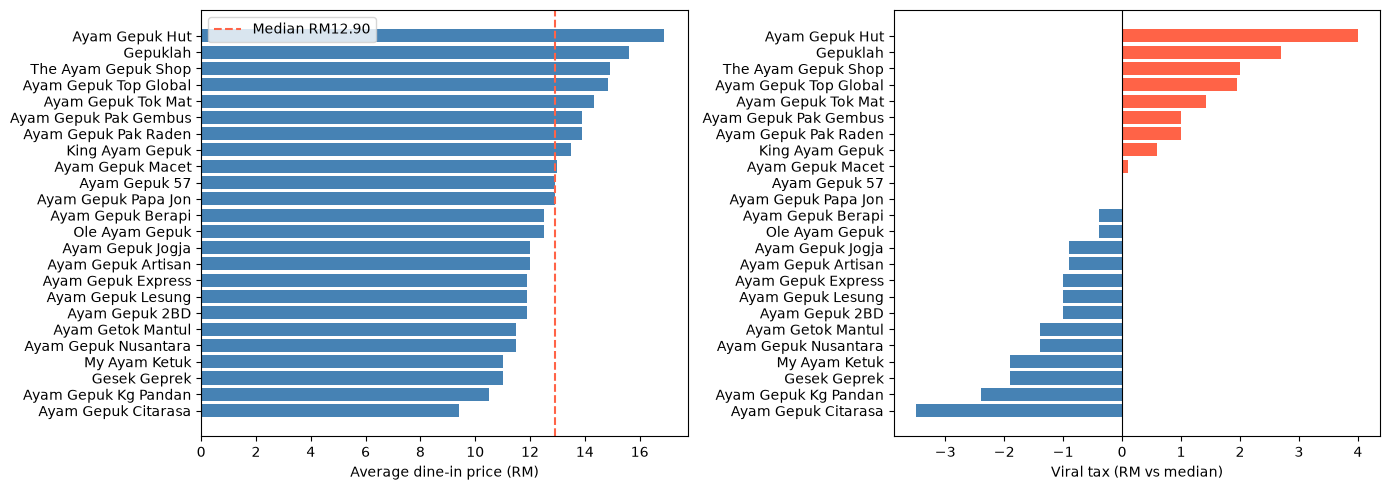

In [3]:
## Price distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

#price by brand
brand_summary_sorted = brand_summary.sort_values("avg_price", ascending=True)
axes[0].barh(brand_summary_sorted.index, brand_summary_sorted["avg_price"], color="steelblue")
axes[0].axvline(12.90, color="tomato", linestyle="--", label="Median RM12.90")
axes[0].set_xlabel("Average dine-in price (RM)")
axes[0].legend()

#viral tax by brand
brand_summary_sorted2 = brand_summary.sort_values("viral_tax", ascending=True)
colors = ["tomato" if v > 0 else "steelblue" for v in brand_summary_sorted2["viral_tax"]]
axes[1].barh(brand_summary_sorted2.index, brand_summary_sorted2["viral_tax"], color=colors)
axes[1].axvline(0, color="black", linewidth=0.8)
axes[1].set_xlabel("Viral tax (RM vs median)")

plt.tight_layout()
plt.show()

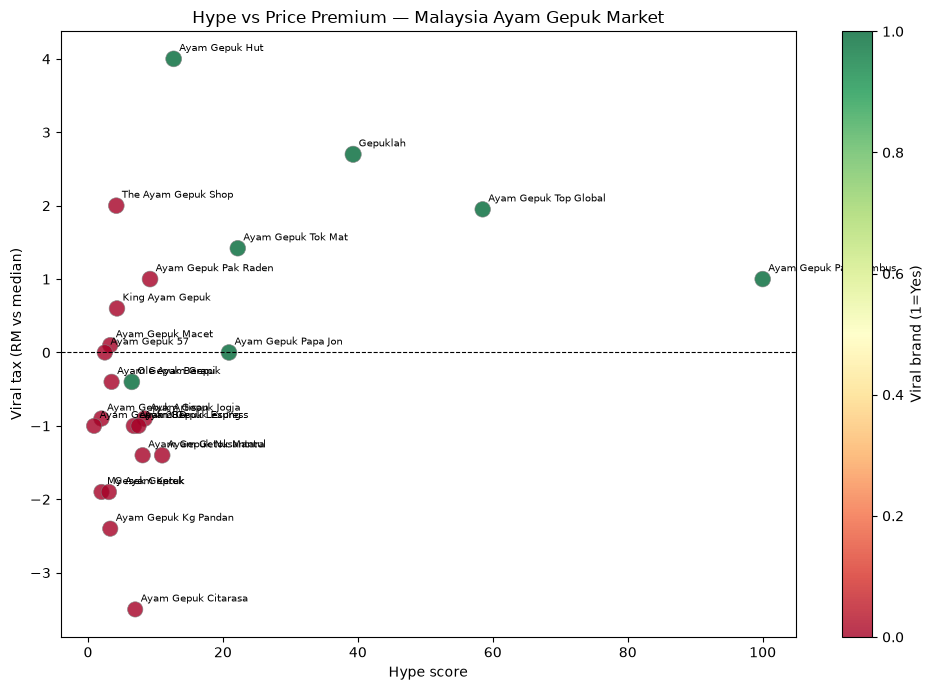

In [4]:
## Hype score vs viral tax
fig, ax = plt.subplots(figsize=(10, 7))

scatter = ax.scatter(
    brand_summary["hype_score"],
    brand_summary["viral_tax"],
    s=brand_summary["avg_rating"] * 30,
    c=brand_summary["viral"],
    cmap="RdYlGn",
    alpha=0.8,
    edgecolors="grey",
    linewidth=0.5
)

for brand, row in brand_summary.iterrows():
    ax.annotate(brand, (row["hype_score"], row["viral_tax"]),
                fontsize=7, ha="left", va="bottom",
                xytext=(4, 4), textcoords="offset points")

ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_xlabel("Hype score")
ax.set_ylabel("Viral tax (RM vs median)")
ax.set_title("Hype vs Price Premium — Malaysia Ayam Gepuk Market")
plt.colorbar(scatter, label="Viral brand (1=Yes)")
plt.tight_layout()
plt.show()

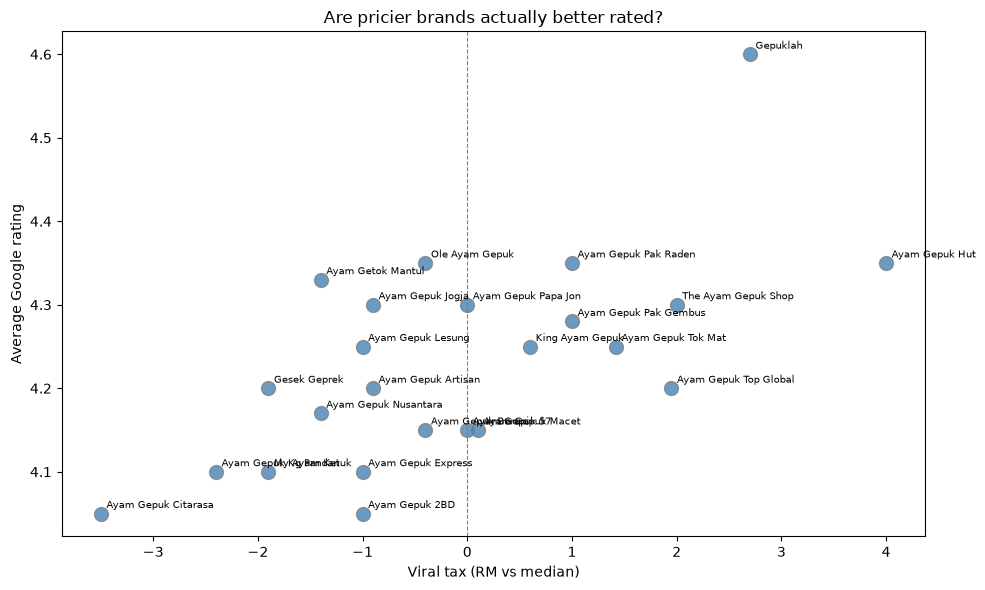


Correlation matrix:
            viral_tax  avg_rating  hype_score  avg_price
viral_tax       1.000       0.650       0.416      1.000
avg_rating      0.650       1.000       0.324      0.650
hype_score      0.416       0.324       1.000      0.416
avg_price       1.000       0.650       0.416      1.000


In [5]:
## Rating vs viral tax — are expensive brands actually better rated?
fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(
    brand_summary["viral_tax"],
    brand_summary["avg_rating"],
    s=100,
    color="steelblue",
    edgecolors="grey",
    alpha=0.8
)

for brand, row in brand_summary.iterrows():
    ax.annotate(brand, (row["viral_tax"], row["avg_rating"]),
                fontsize=7, xytext=(4, 4), textcoords="offset points")

ax.axvline(0, color="grey", linestyle="--", linewidth=0.8)
ax.set_xlabel("Viral tax (RM vs median)")
ax.set_ylabel("Average Google rating")
ax.set_title("Are pricier brands actually better rated?")
plt.tight_layout()
plt.show()

#correlation
corr = brand_summary[["viral_tax","avg_rating","hype_score","avg_price"]].corr()
print("\nCorrelation matrix:")
print(corr.round(3))


Delivery premium per brand (RM extra vs dine-in):
brand
Gepuklah                 2.3
Ayam Gepuk 2BD           2.0
Ayam Gepuk Artisan       2.0
Ayam Gepuk 57            2.0
Ayam Gepuk Citarasa      2.0
Ayam Gepuk Express       2.0
Ayam Gepuk Hut           2.0
Ayam Gepuk Berapi        2.0
Ayam Gepuk Jogja         2.0
Ayam Gepuk Kg Pandan     2.0
Ayam Gepuk Macet         2.0
Ayam Gepuk Lesung        2.0
Ayam Gepuk Pak Gembus    2.0
Ayam Gepuk Pak Raden     2.0
Ayam Gepuk Papa Jon      2.0
Ayam Gepuk Nusantara     2.0
Ayam Gepuk Tok Mat       2.0
Ayam Gepuk Top Global    2.0
Ayam Getok Mantul        2.0
Gesek Geprek             2.0
King Ayam Gepuk          2.0
My Ayam Ketuk            2.0
Ole Ayam Gepuk           2.0
The Ayam Gepuk Shop      2.0
Name: delivery_premium, dtype: float64


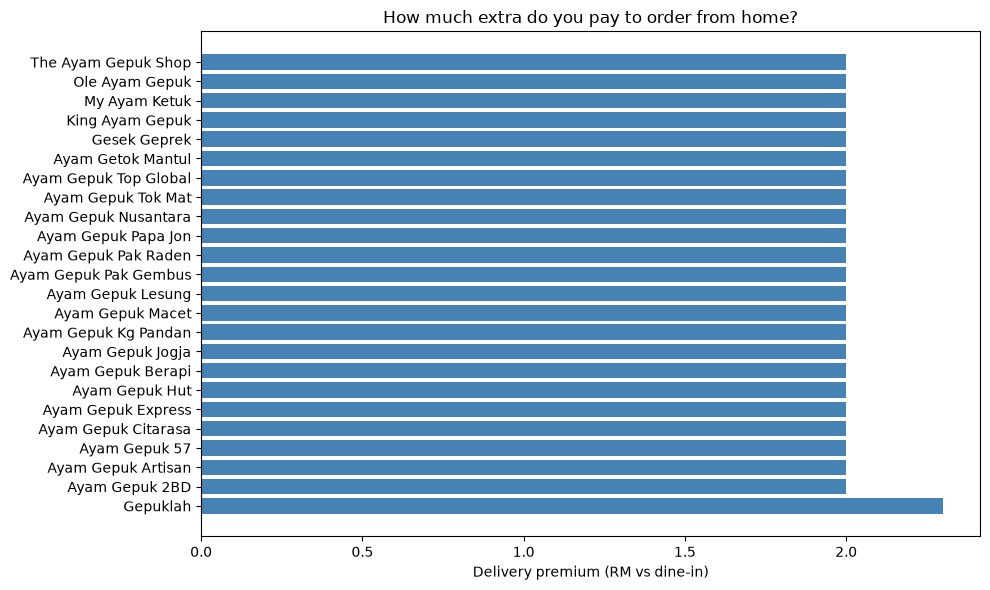

In [6]:
## Delivery premium analysis
df["delivery_premium"] = df["delivery_price_rm"] - df["dine_in_price_rm"]

print("Delivery premium per brand (RM extra vs dine-in):")
print(df.groupby("brand")["delivery_premium"].mean().sort_values(ascending=False).round(2))

#plot
fig, ax = plt.subplots(figsize=(10, 6))
delivery = df.groupby("brand")["delivery_premium"].mean().sort_values(ascending=False)
ax.barh(delivery.index, delivery.values, color="steelblue")
ax.set_xlabel("Delivery premium (RM vs dine-in)")
ax.set_title("How much extra do you pay to order from home?")
plt.tight_layout()
plt.show()